# COGS 108 - EDA Checkpoint

## Authors

- Aaron Soekiatno: Conceptualization, Software, Visualization, Analysis
- Ezra Hong:  Background research, Analysis, Data curation
- Dylan Dwight: Project administration, Experimental investigation, Writing - original draft
- Chon: Software, Methodology, Data curation
- Mai Tamura: Background research, Writing - original draft, Writing - review & editing

# Research Question

Research Question: Do teams that win the first set have a significantly higher chance of winning the match, and how does the match tend to be more competitive due to that (measured by point differential)? Does this pattern continue in the NCAA tournament of the same year?

Metrics/Variables:
Outcome: Match result (win/loss)
Key predictor: First set result (win/loss)
Additional variables: Second set result, set score margin, match format (best of 3)

Analysis Type: This is a descriptive and exploratory analysis task. We will calculate win probabilities for teams based on whether they won or lost the first set. Using bar charts, pie charts, and conditional probability tables, we will visualize how first-set winners perform in the overall match. We can extend the analysis to see if winning the first two sets nearly guarantees victory. The final deliverable will be a dashboard showing momentum patterns and win probabilities at different stages of a match.

## Background and Prior Work

Match competitiveness is a key theme in volleyball analytics. Recent analytics has emphasized measurable indicators of competitiveness—such as point differentials, number of sets played, and home-court effects-to understand how closely intense matches turn out.

Because matches are played as best-of-five sets in certain leagues, early outcomes do not guarantee final results, especially in matches extending beyond three sets. Research in collegiate athletics has also examined the role of home-court advantage in shaping competitive outcomes. Studies across NCAA sports have found that home teams benefit not only in win probability but also in scoring margins. In volleyball specifically, home advantage has been linked to factors such as crowd support, familiarity with the court conditions, and reduced traveling. However, less research has focused on how home or away status affects match competitiveness—particularly in matches that extend beyond three sets.

Additionally, sports analytics literature increasingly uses point differential as a primary indicator of competitiveness. Smaller scoring margins across sets are widely interpreted as signals of evenly matched teams. Analyses in basketball, soccer, and volleyball have demonstrated that attendance and external factors can influence these margins, potentially increasing or decreasing competitive balance.

Our project builds on this prior work by shifting the focus to strictly competitiveness and results of matches that extend to 3 sets. Specifically, we examine whether winning the first set meaningfully predicts match outcomes in extended matches, and whether away teams that win the first set experience more competitive matches, as measured by smaller point differentials when compared to home teams. By concentrating on measurable indicators of competitive intensity, our project aims to provide a clearer understanding of how early advantages shape the competitiveness of NCAA women’s volleyball matches, especially if they are an away team.

# Hypothesis


Hypothesis: Among the 2019 NCAA women's volleyball dataset for matches that extend past 3 sets, the team that won the first set will only have a slightly higher chance to win the match. Additionally, when the away team wins the first set, the match will have a smaller overall point differential, indicating greater competitiveness.

Reasoning: Winning the first set as the away team will likely increase competitiveness and pressure on the opposing team. Additionally, the team that wins the first set has demonstrated early that they can outperform their opponent, which may reflect a  skill advantage that carries through the rest of the match.

## Data

### Data overview

For this project we are analyzing match data from the 2019 NCAA Division I women's volleyball season. Each row of the data set represents a match between two teams and includes information like the teams that played, the location, the points scored each set by both teams, the number of sets won by each team, the match winner, and the attendance.

The dataset contains 4,958 matches and 19 variables. Important variables include the set scores for both teams, the number of sets won by each team, the match location, and the final match outcome. From these variables we can determine which team wont he first set, how many sets were played in the match, and the overall competitveness of the match by calculating the point differentials.

We also looked at a second data set that has the same variables and metrics as our first one, but of matches played in the 2019 NCAA tournament.

Because our research question focuses on matches that extend beyond three sets, we created a new variable called 'total_sets' by summing the sets won by both teams. This way we could filter the dataset to include only matches where 'total+sets >= 4'. This subset represents matches that went to four or five sets and are therefore more competitive.

The cleaned dataset used for analysis contains 531 matches and 20 variables after filtering and preprocessing. We are then going to compare our results with the first dataset to the matches in the 2019 NCAA tournament which we will get data from the second dataset.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/larget/stat-240-case-studies/refs/heads/master/data/vb-division1-2019-all-matches.csv', 'filename':'vball_matches_season.csv'},
    { 'url': 'https://raw.githubusercontent.com/larget/stat-240-case-studies/refs/heads/master/data/vb-division1-2019-ncaa-tourney.csv', 'filename':'vball_matches_tournament.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  5.38it/s]         

Successfully downloaded: vball_matches_season.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  5.56it/s]             


Successfully downloaded: vball_matches_tournament.csv


In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.style.use("fivethirtyeight")

season = pd.read_csv("data/00-raw/ncaa-volleyball-2019.csv")
tournament = pd.read_csv("data/00-raw/ncaa-volleyball-2019-tournament.csv")

print(f"Regular season matches: {len(season)}")
print(f"Tournament matches: {len(tournament)}")
print(f"\nRegular season columns: {list(season.columns)}")
season.head()

Regular season matches: 4958
Tournament matches: 63

Regular season columns: ['date', 'team1', 'team2', 'site', 's1_1', 's1_2', 's1_3', 's1_4', 's1_5', 'sets_1', 's2_1', 's2_2', 's2_3', 's2_4', 's2_5', 'sets_2', 'winner', 'loser', 'attendance']


,date,team1,team2,site,s1_1,s1_2,s1_3,s1_4,s1_5,sets_1,s2_1,s2_2,s2_3,s2_4,s2_5,sets_2,winner,loser,attendance
0,2019-08-30,Northeastern,Green Bay,NaN,16.0,28.0,25.0,23.0,NaN,1,25.0,26.0,27.0,25.0,NaN,3,Green Bay,Northeastern,210.0
1,2019-08-30,South Carolina St.,Texas Southern,"@Montgomery, Ala.",25.0,25.0,12.0,18.0,17.0,2,21.0,20.0,25.0,25.0,19.0,3,Texas Southern,South Carolina St.,0.0
2,2019-08-30,UNLV,Weber St.,NaN,22.0,26.0,17.0,23.0,NaN,1,25.0,24.0,25.0,25.0,NaN,3,Weber St.,UNLV,106.0
3,2019-08-30,SIUE,UC Riverside,"@DeKalb, IL",17.0,20.0,18.0,NaN,NaN,0,25.0,25.0,25.0,NaN,NaN,3,UC Riverside,SIUE,75.0
4,2019-08-30,Temple,Fairfield,"@Baltimore, MD",25.0,25.0,25.0,NaN,NaN,3,20.0,15.0,13.0,NaN,NaN,0,Temple,Fairfield,0.0


In [4]:
def clean_and_engineer(df):
    df = df.copy()

    initial_rows = len(df)

    set_cols = ['s1_1','s1_2','s1_3','s1_4','s1_5',
                's2_1','s2_2','s2_3','s2_4','s2_5']
    for col in set_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    missing_s1 = df['s1_1'].isna() | df['s2_1'].isna()
    if missing_s1.any():
        print(f"  Warning: {missing_s1.sum()} matches missing first-set scores, dropped")
        df = df[~missing_s1].copy()

    df['total_sets'] = df['sets_1'] + df['sets_2']

    invalid_sets = ~df['total_sets'].isin([3, 4, 5])
    if invalid_sets.any():
        print(f"  Warning: {invalid_sets.sum()} matches with invalid set count, dropped")
        df = df[~invalid_sets].copy()

    tied_first_set = df['s1_1'] == df['s2_1']
    if tied_first_set.any():
        print(f"  Warning: {tied_first_set.sum()} matches with tied first set, dropped")
        df = df[~tied_first_set].copy()

    df['first_set_winner'] = np.where(df['s1_1'] > df['s2_1'], df['team1'], df['team2'])
    df['first_set_winner_won_match'] = df['first_set_winner'] == df['winner']
    df['extended_match'] = df['total_sets'] > 3

    df['point_diff'] = 0

    for i in range(1, 6):
        s1_col, s2_col = f's1_{i}', f's2_{i}'
        mask = df[s1_col].notna() & df[s2_col].notna()

        df.loc[mask, 'point_diff'] += np.abs(df.loc[mask, s1_col] - df.loc[mask, s2_col])

        df[f'set{i}_diff'] = df[s1_col] - df[s2_col]

    df['first_set_margin'] = np.abs(df['s1_1'] - df['s2_1'])

    if 'site' in df.columns:
        df['site'] = df['site'].fillna('')
        df['team1_is_away'] = df['site'].str.startswith('@')
        df['first_set_winner_is_away'] = (
            ((df['first_set_winner'] == df['team1']) & df['team1_is_away']) |
            ((df['first_set_winner'] == df['team2']) & ~df['team1_is_away'])
        )
    else:
        df['team1_is_away'] = False
        df['first_set_winner_is_away'] = False

    rows_dropped = initial_rows - len(df)
    if rows_dropped > 0:
        print(f"  Total rows dropped: {rows_dropped} of {initial_rows}")
    else:
        print(f"  Data quality check passed: all {initial_rows} matches valid")

    return df

In [5]:
season = clean_and_engineer(season)
tournament = clean_and_engineer(tournament)

  Total rows dropped: 21 of 4958
  Data quality check passed: all 63 matches valid


The clean_and_engineer function applies identical transformations to both datasets. Key derived features include:

* total_sets: Number of sets played (3, 4, or 5). Extended matches (4-5 sets) are our focus for RQ1.
* first_set_winner: The team that scored more points in set 1.
* first_set_margin: How decisively the first set was won (absolute point difference in set 1). This lets us explore whether a dominant first-set win carries a different advantage than a narrow one.
* point_diff: Sum of absolute point differences across all played sets. This is our competitiveness metric for RQ2.
* set1_diff through set5_diff: Per-set point differentials (from team1's perspective), enabling set-by-set competitiveness analysis.
* first_set_winner_is_away: Whether the first-set winner was the visiting team, for RQ2.

The regular season provides roughly 80x more matches than the tournament, so all primary statistical tests will use regular-season data. The tournament serves purely as a validation check.

## Results

### Exploratory Data Analysis

In this section, we explore the cleaned and processed dataset we made using our clean_and_engineer function in order to understand the structure of the data and identify patterns relevant to our research question.

The exploratory data analysis focuses on understanding the relationship between the team that wins the first set and the eventual match outcome, particularly for matches that extend beyond three sets. We also explore whether matches become more competitive when the away team wins the first set, using point differential as a measure of competitiveness.

To accomplish this, we perform several exploratory steps:
* Summary Statistics: We calculate descriptive statistics for key variables such as match outcome, number of sets played, and point differential. This helps us understand the distribution and central tendencies of the data.
* Distribution Exploration: We visualize distributions of variables such as set wins and point differentials to detect skewness, outliers, or unusual patterns that may influence the analysis.
* Visualization of Relationships: We generate plots and graphs to illustrate relationships between variables like win rates for teams that win the first set, point differentials in matches where the away team wins the first set, and differences between home and away performance.

These exploratory analyses allow us to identify patterns and potential relationships in the data before moving on to more formal statistical analysis. The goal of the EDA stage is to build intuition about the dataset and ensure that our modeling and hypothesis testing steps are informed by the observed structure of the data.

## Section 1 of EDA - Does winning the first set increase probability of winning the match?

We begin by examining how often the team that wins the first set goes on to win the match, broken down by the total number of sets played. Our focus is on extended matches (4 and 5 sets), where the contest was close enough that neither team swept.

We use a colored bar chart for this initial breakdown because it clearly shows the count and proportion in each category. Bar charts are the most appropriate choice here since we are comparing frequencies across a small number of discrete categories (3-, 4-, and 5-set matches).

Match length distribution (regular season):
  3-set matches: 2365 (47.9%)
  4-set matches: 1543 (31.3%)
  5-set matches: 1029 (20.8%)


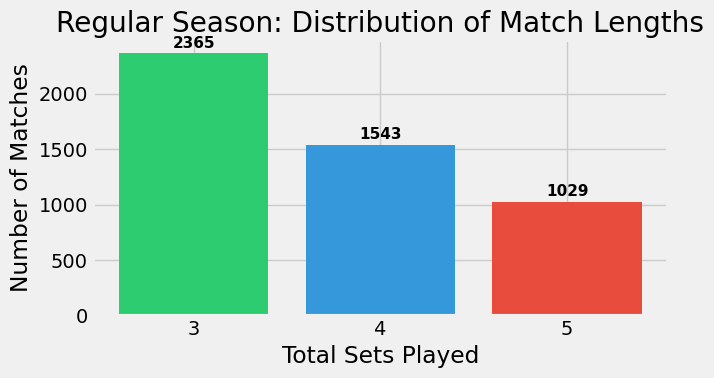

In [6]:
set_counts = season['total_sets'].value_counts().sort_index()
print("Match length distribution (regular season):")
for sets, count in set_counts.items():
    print(f"  {sets}-set matches: {count} ({count/len(season):.1%})")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(set_counts.index.astype(str), set_counts.values, color=['#2ecc71', '#3498db', '#e74c3c'])
ax.set_xlabel('Total Sets Played')
ax.set_ylabel('Number of Matches')
ax.set_title('Regular Season: Distribution of Match Lengths')
for bar, val in zip(bars, set_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

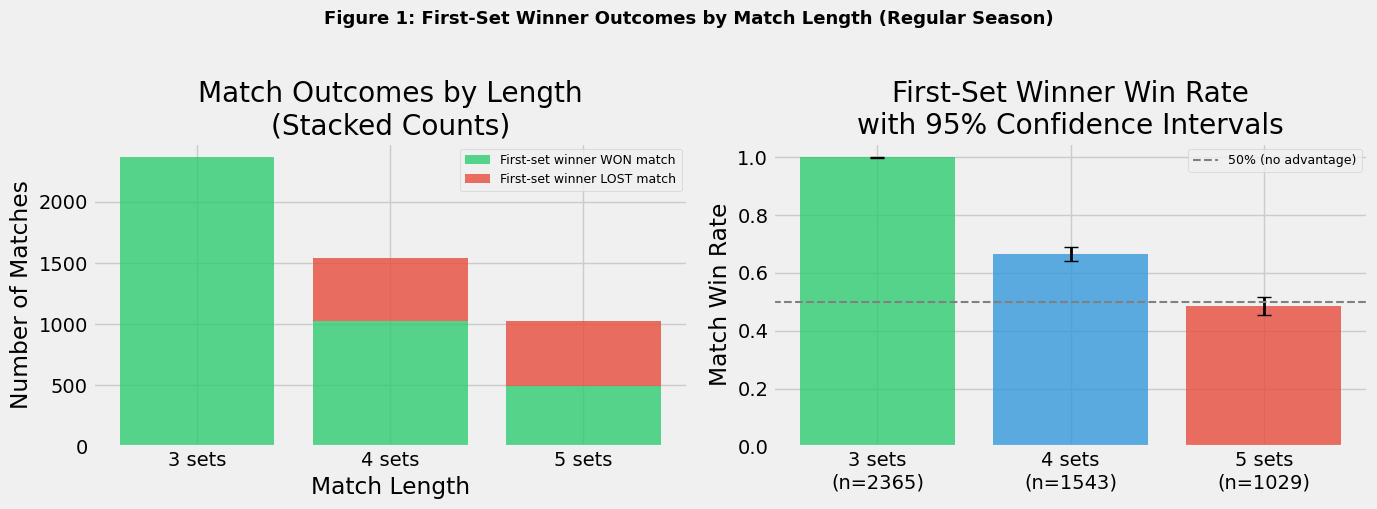

In [7]:
win_rates = season.groupby('total_sets')['first_set_winner_won_match'].agg(['sum', 'count'])
win_rates.columns = ['wins', 'total']
win_rates['losses'] = win_rates['total'] - win_rates['wins']
win_rates['win_rate'] = win_rates['wins'] / win_rates['total']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_palette = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']

ax = axes[0]
x = np.arange(len(win_rates))
ax.bar(x, win_rates['wins'], label='First-set winner WON match', color='#2ecc71', alpha=0.8)
ax.bar(x, win_rates['losses'], bottom=win_rates['wins'], label='First-set winner LOST match', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{s} sets' for s in win_rates.index])
ax.set_xlabel('Match Length')
ax.set_ylabel('Number of Matches')
ax.set_title('Match Outcomes by Length\n(Stacked Counts)')
ax.legend(fontsize=9)

ax = axes[1]
for i, (sets, row) in enumerate(win_rates.iterrows()):
    p = row['win_rate']
    n = row['total']
    ci = stats.binomtest(int(row['wins']), int(n), p=0.5).proportion_ci(confidence_level=0.95, method='wilson')
    ax.bar(i, p, color=colors_palette[i % len(colors_palette)], alpha=0.8)
    ax.errorbar(i, p, yerr=[[p - ci.low], [ci.high - p]], fmt='none', color='black', capsize=5, linewidth=2)

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='50% (no advantage)')
ax.set_xticks(range(len(win_rates)))
ax.set_xticklabels([f'{s} sets\n(n={int(win_rates.loc[s, "total"])})' for s in win_rates.index])
ax.set_ylabel('Match Win Rate')
ax.set_title('First-Set Winner Win Rate\nwith 95% Confidence Intervals')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

plt.suptitle('Figure 1: First-Set Winner Outcomes by Match Length (Regular Season)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 1** presents the match outcomes by length. The left panel shows the raw counts: in 3-set sweeps, first-set winners overwhelmingly won, while in 4- and 5-set matches the split is more even. The right panel is more informative: it shows the win rate with 95% Wilson confidence intervals. The key question is whether the confidence intervals for extended matches lie entirely above the 50% line (gray dashed). If so, we have evidence that the first-set advantage is real and not just noise.

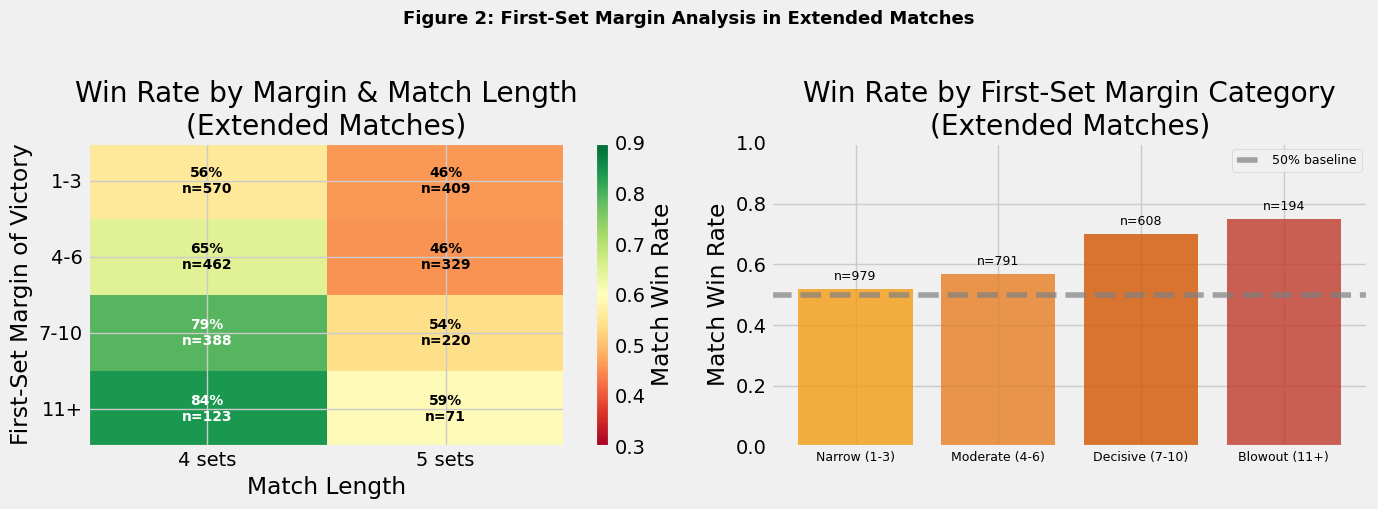

In [8]:
ext_season = season[season['extended_match']].copy()

ext_season['margin_bin'] = pd.cut(ext_season['first_set_margin'], 
                                   bins=[0, 3, 6, 10, 30],
                                   labels=['Narrow (1-3)', 'Moderate (4-6)', 'Decisive (7-10)', 'Blowout (11+)'],
                                   right=True)

margin_rates = ext_season.groupby('margin_bin', observed=True)['first_set_winner_won_match'].agg(['mean', 'count'])
margin_rates.columns = ['win_rate', 'n_matches']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ext = ext_season.copy()
ext['margin_bin'] = pd.cut(ext['first_set_margin'], bins=[0, 3, 6, 10, 30], 
                           labels=['1-3', '4-6', '7-10', '11+'])
heatmap_data = ext.groupby(['margin_bin', 'total_sets'])['first_set_winner_won_match'].mean().unstack(fill_value=0)

im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0.3, vmax=0.9)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f'{s} sets' for s in heatmap_data.columns])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel('Match Length')
ax.set_ylabel('First-Set Margin of Victory')
ax.set_title('Win Rate by Margin & Match Length\n(Extended Matches)')

counts = ext.groupby(['margin_bin', 'total_sets'])['first_set_winner_won_match'].count().unstack(fill_value=0)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        n = int(counts.values[i, j])
        text_color = 'white' if val > 0.7 or val < 0.4 else 'black'
        ax.text(j, i, f'{val:.0%}\nn={n}', ha='center', va='center', 
                fontsize=10, fontweight='bold', color=text_color)
plt.colorbar(im, ax=ax, label='Match Win Rate')

ax = axes[1]
x = np.arange(len(margin_rates))
colors_bar = ['#f39c12', '#e67e22', '#d35400', '#c0392b']
bars = ax.bar(x, margin_rates['win_rate'], color=colors_bar, alpha=0.8)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% baseline')
ax.set_xticks(x)
ax.set_xticklabels(margin_rates.index, fontsize=9)
ax.set_ylabel('Match Win Rate')
ax.set_title('Win Rate by First-Set Margin Category\n(Extended Matches)')
ax.set_ylim(0, 1)
for bar, (_, row) in zip(bars, margin_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'n={int(row["n_matches"])}', ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=9)

plt.suptitle('Figure 2: First-Set Margin Analysis in Extended Matches',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Figure 2** explores first-set margin in extended matches. The left panel is a heatmap that cross-tabulates first-set margin bins (rows) against match length (columns), with each cell colored by the first-set winner's match win rate. This allows us to see at a glance whether larger first-set margins correspond to higher win rates, and whether this effect differs between 4- and 5-set matches. The right panel presents the same data as a colored bar chart grouped by margin category, making it easy to compare win rates across bins.


The takeaway is that the advantage is graded, not binary. Teams that barely win the first set have a much smaller edge than teams that win it convincingly. This makes sense because a narrow first-set win (like 26-24) suggests the teams are very evenly matched, while a blowout (like 25-15) suggests one team is clearly stronger.

## Section 2 of EDA - Tournment Validation

We now test whether the patterns found in the regular season hold up in the 2019 NCAA tournament. The tournament is a single-elimination bracket with only 63 matches, so we cannot achieve the same statistical power. Instead, we treat this as a directional consistency check. Do the tournament results align with the regular-season findings, even if the small sample prevents statistical significance?

Why validate with tournament data? Using a separate dataset (the tournament) to check our regular-season findings guards against overfitting our conclusions to one particular dataset. If the same patterns appear in both the regular season (large sample, high power) and the tournament (small sample, different competitive context), we can be more confident that the effects are real and generalizable rather than artifacts of a specific dataset.

In [9]:
t_set_counts = tournament['total_sets'].value_counts().sort_index()
print("Tournament match length distribution:")
for sets, count in t_set_counts.items():
    print(f"  {sets}-set matches: {count} ({count/len(tournament):.1%})")

t_win_rates = tournament.groupby('total_sets')['first_set_winner_won_match'].agg(['mean', 'sum', 'count'])
t_win_rates.columns = ['win_rate', 'wins', 'total']
print(f"\nTournament: First-set winner win rates by match length:")
print(t_win_rates)
print(f"\nOverall tournament first-set winner win rate: {tournament['first_set_winner_won_match'].mean():.1%}")

Tournament match length distribution:
  3-set matches: 38 (60.3%)
  4-set matches: 12 (19.0%)
  5-set matches: 13 (20.6%)

Tournament: First-set winner win rates by match length:
            win_rate  wins  total
total_sets                       
3           1.000000    38     38
4           0.500000     6     12
5           0.538462     7     13

Overall tournament first-set winner win rate: 81.0%


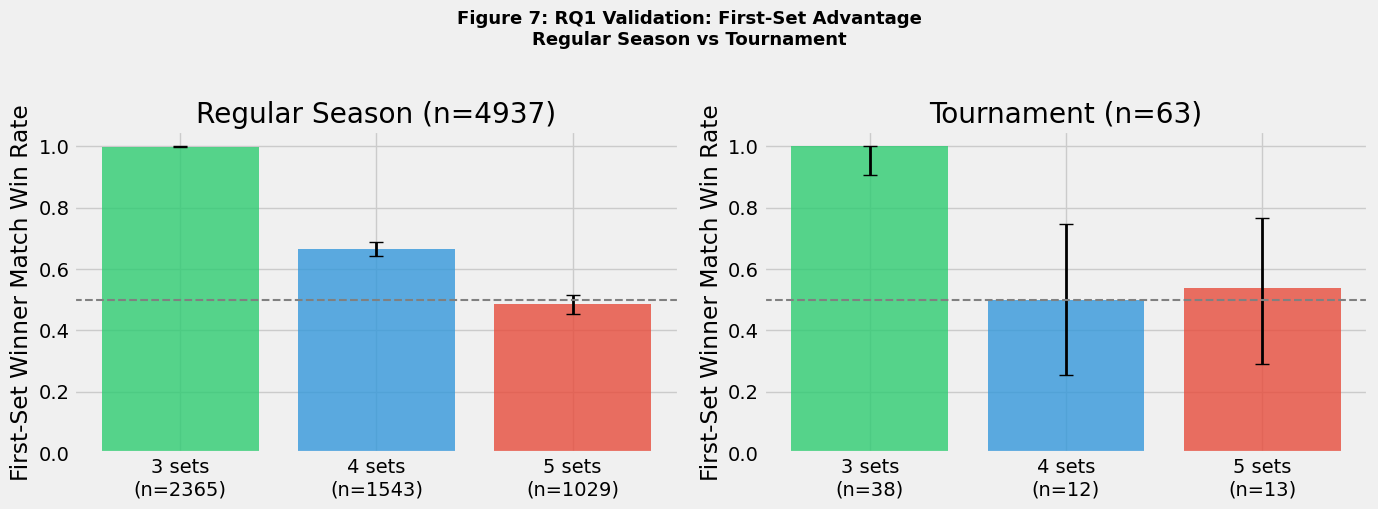

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_palette = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']

for ax, data, title in zip(axes, [season, tournament], ['Regular Season (n={})'.format(len(season)), 
                                                          'Tournament (n={})'.format(len(tournament))]):
    wr = data.groupby('total_sets')['first_set_winner_won_match'].agg(['mean', 'sum', 'count'])
    wr.columns = ['win_rate', 'wins', 'total']
    
    for i, (sets, row) in enumerate(wr.iterrows()):
        p = row['win_rate']
        n = int(row['total'])
        w = int(row['wins'])
        ci = stats.binomtest(w, n, p=0.5).proportion_ci(confidence_level=0.95, method='wilson')
        ax.bar(i, p, color=colors_palette[i % len(colors_palette)], alpha=0.8)
        ax.errorbar(i, p, yerr=[[p - ci.low], [ci.high - p]], fmt='none', 
                     color='black', capsize=5, linewidth=2)
    
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
    ax.set_xticks(range(len(wr)))
    ax.set_xticklabels([f'{s} sets\n(n={int(wr.loc[s, "total"])})' for s in wr.index])
    ax.set_ylabel('First-Set Winner Match Win Rate')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)

plt.suptitle('Figure 7: RQ1 Validation: First-Set Advantage\nRegular Season vs Tournament',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 7** places the regular season and tournament side by side with identical axes, making it easy to compare. Note the much wider confidence intervals in the tournament panel, a direct consequence of the small sample size (63 matches vs. nearly 5,000). Even if the point estimates differ between season and tournament, overlapping confidence intervals would suggest the results are consistent.

The key question is not whether the tournament numbers exactly match the regular season, but whether they point in the same direction. If the tournament shows a similar pattern (high win rate in 3-set, moderate in 4-set, near 50% in 5-set), it supports the generalizability of our findings beyond just the regular season.

## Ethics

Data Collection:
The datasets used in this project contains match results from NCAA Division 1 women's volleyball during the 2019 season and postseason. Because the data describes sporting events rather than individual's private information, there are no direct concerns regarding informed consent or personal informatiuon. The dataset includes team names, match locations, set scores, and attendance, none of which identify individual atheles or fans.

However bias may still exist. The dataset only includes matches from the 2019 season/postseason which means our analyssi may not generalize to other seasons or different levels of competition. Also, the attendance data may be inconsistently reported across stadiums, which could introduce measurement bias.

Data Storage and Security:
The dataset is stored locally within the project repository in the data/00-raw directory and processed versions are saved in data/02-processed. Because the dataset does not contain personal information, there are minimal risks related to data security or privacy. Nevertheless, maintaining a clear workflow and version control ensures that the analysis is reproducible and that modifications to the dataset are documented.

Analysis Considerations:
One potential limitation of our analysis is that the dataset does not include variables related to team skill level, rankings, conference strength, injuries, or coaching strategies. These factors may influence both the outcome of the first set and the final match result. As a result, correlations observed in the analysis should not be interpreted as causal relationships.

## Team Expectations 

Team Expectation 1 For communication, we will mainly use Instagram, and we expect response times to be around 24 hours.

Team Expectation 2 We expect to provide and receive polite feedback from our group members.

Team Expectation 3 We divided up tasks evenly throughout the proposal, but it is subject to change as we work on the project.

Team Expectation 4 If anyone is falling behind and or can't meet a certain deadline, we all agreed that they need to notify the group at least a day before.

## Project Timeline Proposal

Week 1:
We finalized our research question and identified the datasets we would use. We chose the 2019 NCAA Division I women’s volleyball regular season and tournament match datasets.

Week 2:
We loaded both datasets into Python and performed basic data cleaning. We removed rows with missing site values and created a total_sets variable to calculate the total number of sets played in each match.

Week 3:
We filtered the datasets to include only competitive matches (matches with 4 or more sets). We also began exploratory data analysis by determining the first set winner and the overall match winner.

Week 4:
We will continue our exploratory analysis by examining the relationship between first set winners, match outcomes, and match competitiveness.

Week 5:
We will finalize our analysis, create visualizations, and write the final report explaining our results.